In [16]:
import numpy as np
import pandas as pd

In [17]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [18]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

In [19]:
def create_date_features(df):
    df['month'] = df.date.dt.month
    df['day_of_month'] = df.date.dt.day
    df['day_of_year'] = df.date.dt.dayofyear
    df['week_of_year'] = df.date.dt.isocalendar().week.astype(int)
    df['day_of_week'] = df.date.dt.dayofweek
    df['year'] = df.date.dt.year
    df["is_wknd"] = df.date.dt.dayofweek // 5
    df['is_month_start'] = df.date.dt.is_month_start.astype(int)
    df['is_month_end'] = df.date.dt.is_month_end.astype(int)
    return df

def random_noise(dataframe):
    return np.random.normal(scale=1.6, size=(len(dataframe),))

def lag_features(dataframe, lags):
    for lag in lags:
        dataframe['sales_lag_' + str(lag)] = dataframe.groupby(["store", "item"])['sales'].transform(
            lambda x: x.shift(lag)) + random_noise(dataframe)
    return dataframe

def roll_mean_features(dataframe, windows):
    for window in windows:
        dataframe['sales_roll_mean_' + str(window)] = dataframe.groupby(["store", "item"])['sales']. \
                                                          transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=10, win_type="triang").mean()) + random_noise(
            dataframe)
    return dataframe

def ewm_features(dataframe, alphas, lags):
    for alpha in alphas:
        for lag in lags:
            dataframe['sales_ewm_alpha_' + str(alpha).replace(".", "") + "_lag_" + str(lag)] = \
                dataframe.groupby(["store", "item"])['sales'].transform(lambda x: x.shift(lag).ewm(alpha=alpha).mean())
    return dataframe

In [20]:
# Test setinde sales sütunu olmadığı için NaN olarak ekliyoruz
test['sales'] = np.nan

# İkisini alt alta birleştiriyoruz
df = pd.concat([train, test], sort=False)

In [21]:
# 1. Date Features
df = create_date_features(df)

# 2. Lag Features (df üzerinde)
lags = [91, 98, 105, 112, 119, 126, 182, 364, 546, 728]
df = lag_features(df, lags)

# 3. Rolling Mean
df = roll_mean_features(df, [365, 546])

# 4. EWM
alphas = [0.95, 0.9, 0.8, 0.5]
lags = [91, 98, 105, 112, 180, 270, 365]
df = ewm_features(df, alphas, lags)

In [22]:
# Kategorik değişkenleri modelin anlayacağı formata getiriyoruz
df = pd.get_dummies(df, columns=['store', 'item', 'day_of_week', 'month'])

# Tekrar ayırıyoruz
train = df[df['sales'].notnull()]
test = df[df['sales'].isnull()]

In [23]:
# Satışların logaritmasını alarak varyansı normalize edelim (Model daha iyi öğrenir)
train['sales'] = np.log1p(train['sales'])

# Modelde kullanılmayacak sütunlar
cols = [col for col in train.columns if col not in ['date', 'id', 'sales', 'year']]

Y_train = train['sales']
X_train = train[cols]

X_test = test[cols]

In [24]:
# 2017'nin başına kadar eğitim, sonrası doğrulama (validation)
mask = (train['date'] < '2017-10-01')
X_train_final = X_train[mask]
Y_train_final = Y_train[mask]

X_val = X_train[~mask]
Y_val = Y_train[~mask]

In [25]:
import lightgbm as lgb

# Hiperparametreler (Genel kabul görmüş başlangıç değerleri)
lgb_params = {'num_leaves': 10,
              'learning_rate': 0.02,
              'feature_fraction': 0.8,
              'max_depth': 5,
              'verbose': 0,
              'num_boost_round': 1000,
              'early_stopping_rounds': 200,
              'nthread': -1}

lgbtrain = lgb.Dataset(data=X_train_final, label=Y_train_final, feature_name=cols)
lgbval = lgb.Dataset(data=X_val, label=Y_val, reference=lgbtrain, feature_name=cols)

model = lgb.train(lgb_params, lgbtrain,
                  valid_sets=[lgbtrain, lgbval],
                  num_boost_round=lgb_params['num_boost_round'],
                  callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(100)])

Training until validation scores don't improve for 200 rounds
[100]	training's l2: 0.0502203	valid_1's l2: 0.0389996
[200]	training's l2: 0.0344846	valid_1's l2: 0.0297267
[300]	training's l2: 0.0317465	valid_1's l2: 0.0285184
[400]	training's l2: 0.0307444	valid_1's l2: 0.0279035
[500]	training's l2: 0.0301324	valid_1's l2: 0.0275086
[600]	training's l2: 0.0296786	valid_1's l2: 0.027183
[700]	training's l2: 0.0293284	valid_1's l2: 0.0269722
[800]	training's l2: 0.0290335	valid_1's l2: 0.0268116
[900]	training's l2: 0.0287898	valid_1's l2: 0.0266597
[1000]	training's l2: 0.0285804	valid_1's l2: 0.026527
Did not meet early stopping. Best iteration is:
[1000]	training's l2: 0.0285804	valid_1's l2: 0.026527


In [26]:
def smape(preds, target):
    n = len(preds)
    masked_arr = ~((preds == 0) & (target == 0))
    preds, target = preds[masked_arr], target[masked_arr]
    num = np.abs(preds - target)
    den = (np.abs(preds) + np.abs(target)) / 2
    return 100 / n * np.sum(num / den)

# Tahminleri al ve logdan geri döndür
val_preds = model.predict(X_val)
error = smape(np.expm1(val_preds), np.expm1(Y_val))
print(f"Validation SMAPE: {error:.4f}")

Validation SMAPE: 12.7473


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

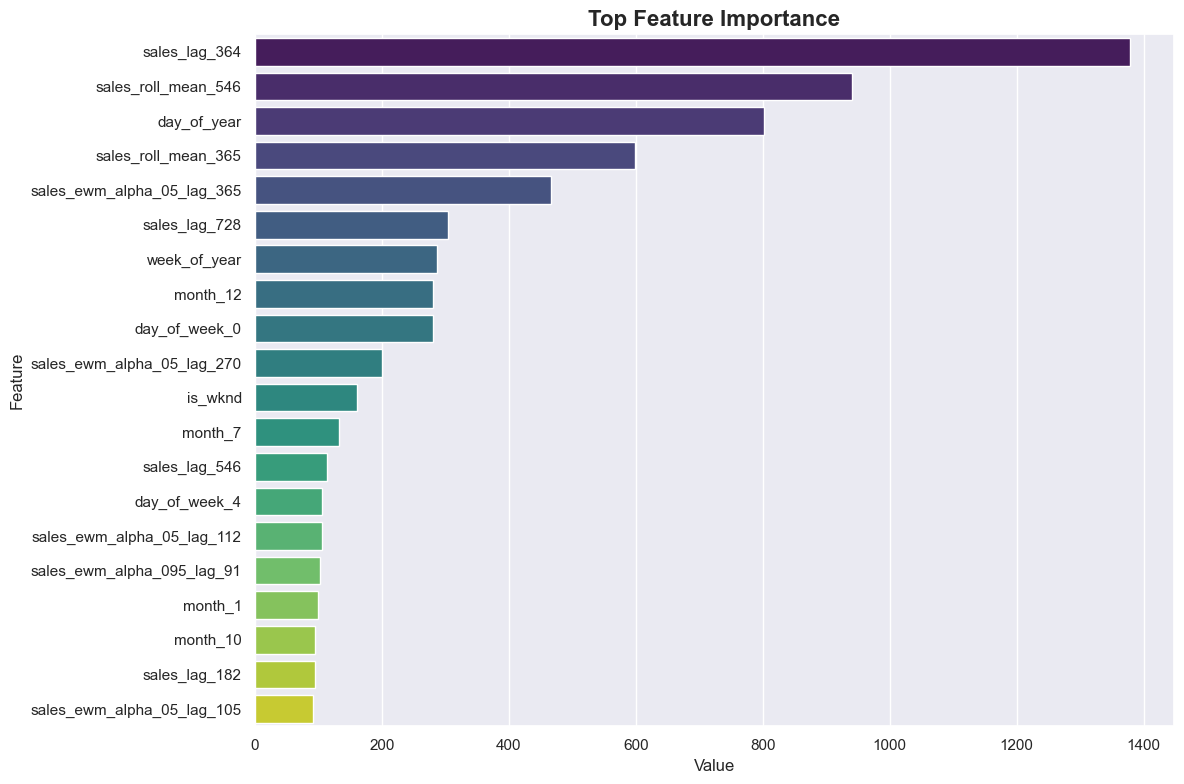

In [29]:
import os

def plot_lgb_importances(model, num=10, save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importance(), 'Feature': X_train.columns})
    plt.figure(figsize=(12, 8))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False)[0:num], palette='viridis')
    plt.title('Top Feature Importance', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save:
        # Klasör var mı kontrol et, yoksa oluştur
        if not os.path.exists('../reports'):
            os.makedirs('../reports')
        plt.savefig('../reports/feature_importance.png')
        
    plt.show()

plot_lgb_importances(model, num=20, save=True)

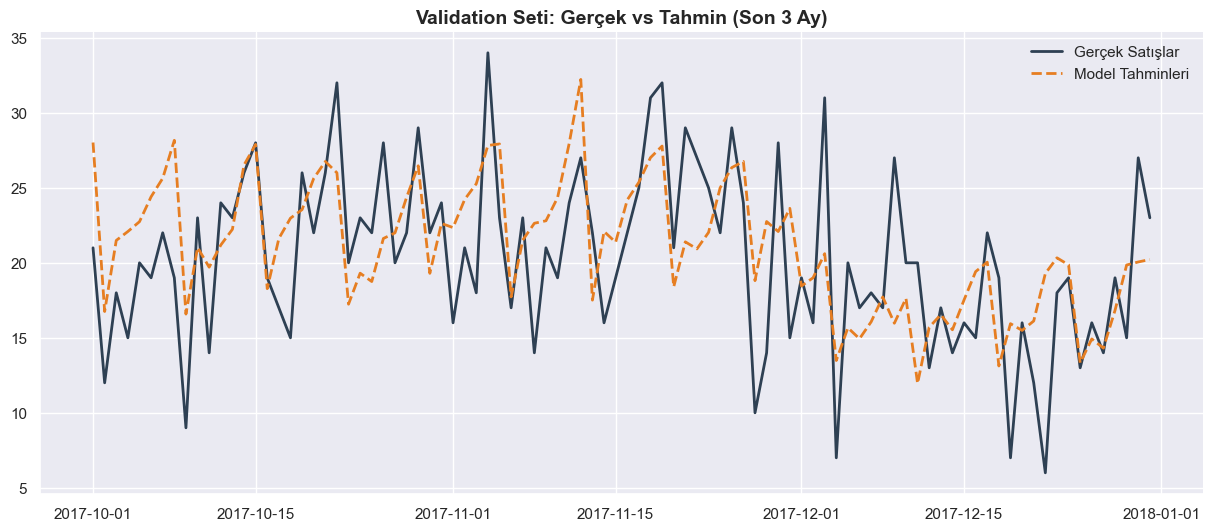

In [30]:
# Tahminleri ve gerçek değerleri birleştirme
final_df = pd.DataFrame({'date': train[~mask]['date'], 
                         'actual': np.expm1(Y_val), 
                         'pred': np.expm1(val_preds)})

# Sadece bir mağaza ve bir ürün için görselleştirelim (Karmaşayı önlemek için)
# Örn: Store 1, Item 1
sample_df = final_df.iloc[:92] # İlk 3 ay (bir mağaza/ürün kombinasyonu için yaklaşık 92 gün)

plt.figure(figsize=(15, 6))
plt.plot(sample_df['date'], sample_df['actual'], label='Gerçek Satışlar', color='#2E4053', linewidth=2)
plt.plot(sample_df['date'], sample_df['pred'], label='Model Tahminleri', color='#E67E22', linestyle='--', linewidth=2)
plt.title('Validation Seti: Gerçek vs Tahmin (Son 3 Ay)', fontsize=14, fontweight='bold')
plt.legend(frameon=False)
sns.despine()
plt.show()

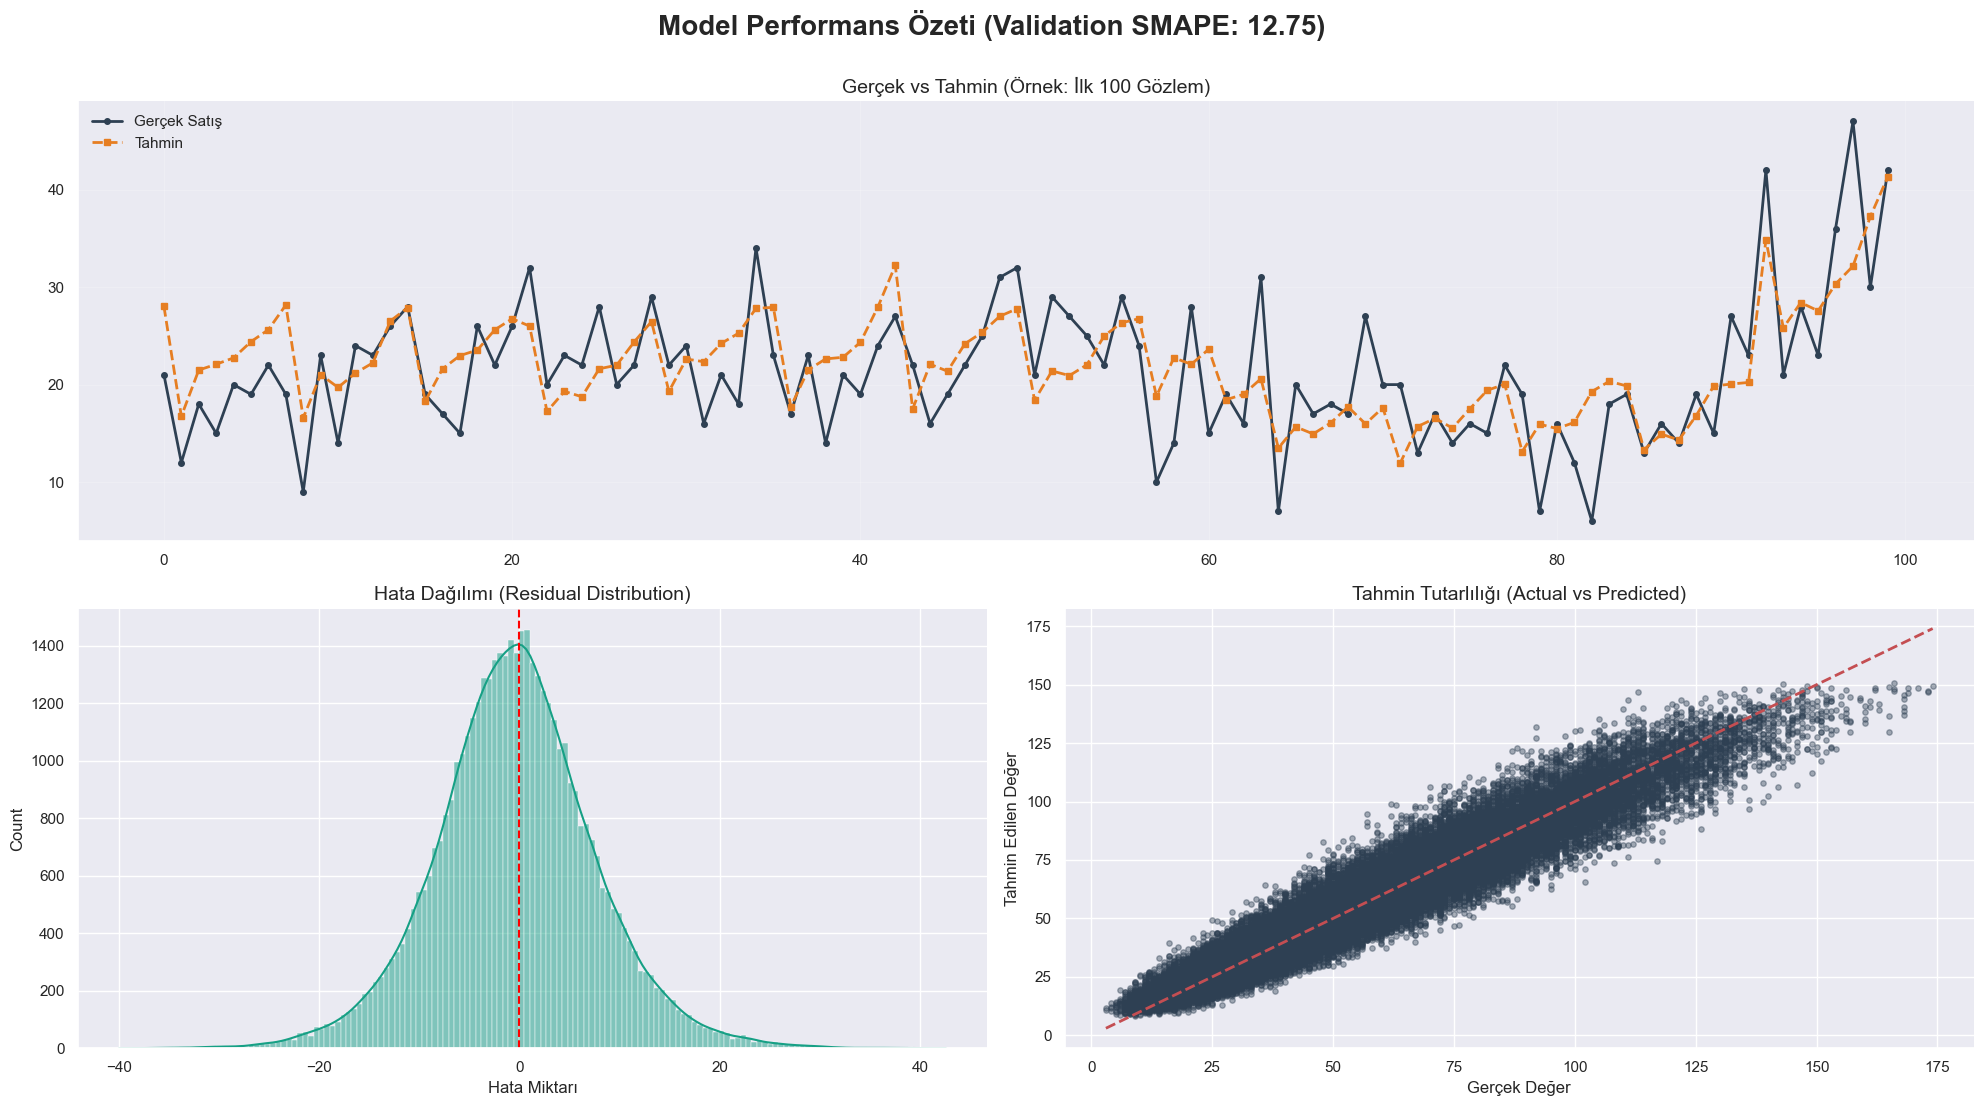

In [31]:
# 1. Hazırlık: Verileri Toplayalım
results_df = pd.DataFrame({
    'Actual': np.expm1(Y_val),
    'Predicted': np.expm1(val_preds)
})
results_df['Error'] = results_df['Actual'] - results_df['Predicted']

# 2. Dashboard Tasarımı
fig = plt.figure(figsize=(20, 12))
plt.suptitle(f'Model Performans Özeti (Validation SMAPE: {error:.2f})', fontsize=20, fontweight='bold', y=0.95)

# --- A. Gerçek vs Tahmin (Zaman Serisi) ---
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
# Daha temiz görünüm için ilk 100 veriyi örnekleyelim
ax1.plot(results_df['Actual'].values[:100], label='Gerçek Satış', color='#2E4053', linewidth=2, marker='o', markersize=4)
ax1.plot(results_df['Predicted'].values[:100], label='Tahmin', color='#E67E22', linestyle='--', linewidth=2, marker='s', markersize=4)
ax1.set_title('Gerçek vs Tahmin (Örnek: İlk 100 Gözlem)', fontsize=14)
ax1.legend(frameon=False)
ax1.grid(alpha=0.2)

# --- B. Hata Dağılımı (Histogram) ---
ax2 = plt.subplot2grid((2, 2), (1, 0))
sns.histplot(results_df['Error'], kde=True, ax=ax2, color='#16A085')
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title('Hata Dağılımı (Residual Distribution)', fontsize=14)
ax2.set_xlabel('Hata Miktarı')

# --- C. Hata vs Gerçek Değer (Scatter) ---
ax3 = plt.subplot2grid((2, 2), (1, 1))
ax3.scatter(results_df['Actual'], results_df['Predicted'], alpha=0.4, color='#2E4053', s=15)
ax3.plot([results_df['Actual'].min(), results_df['Actual'].max()], 
         [results_df['Actual'].min(), results_df['Actual'].max()], 
         'r--', lw=2) # İdeal çizgi
ax3.set_title('Tahmin Tutarlılığı (Actual vs Predicted)', fontsize=14)
ax3.set_xlabel('Gerçek Değer')
ax3.set_ylabel('Tahmin Edilen Değer')

# Estetik Dokunuşlar
sns.despine()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Kaydetme
if not os.path.exists('../reports'):
    os.makedirs('../reports')
plt.savefig('../reports/model_performance_dashboard.png', dpi=300)
plt.show()